### 1. SETUP Y CONFIGURACIÓN


##### 1.1 Imports

In [ ]:
# Core
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
from pathlib import Path

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import models

# Image processing
from PIL import Image
from skimage import color, io
import cv2

# Metrics
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.color import deltaE_ciede2000  

# Utils
import warnings
warnings.filterwarnings('ignore')

# Verificar versiones
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

from utils import rgb_to_lab, lab_to_rgb

PyTorch version: 2.9.1+cu128
Torchvision version: 0.24.1+cu128
CUDA available: True


##### 1.2 Configuración de Seeds


In [ ]:
def set_seed(seed=42):
    """
    Configura seeds para reproducibilidad.
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Seed configurada: {seed}")

# Aplicar seed
set_seed(42)

Seed configurada: 15


In [ ]:
class Config:
    """
    Configuración global del proyecto.
    """
    # Paths
    DATA_DIR = Path("data/raw")
    SAMPLES_DIR = Path("data/samples")
    
    # Dataset
    IMG_SIZE = 256  
    BATCH_SIZE = 16  
    NUM_WORKERS = 4  
    
    # Training
    NUM_EPOCHS = 25  
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4
    
    # Model
    BACKBONE = "resnet50"  
    PRETRAINED = True
    
    # Early stopping
    PATIENCE = 10
    
    # Reproducibilidad
    SEED = 42

config = Config()

print(" Configuración:")
print(f"  - Tamaño de imagen: {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"  - Batch size: {config.BATCH_SIZE}")
print(f"  - Learning rate: {config.LEARNING_RATE}")
print(f"  - Backbone: {config.BACKBONE}")
print(f"  - Epochs: {config.NUM_EPOCHS}")

 Configuración:
  - Tamaño de imagen: 256x256
  - Batch size: 16
  - Learning rate: 0.001
  - Backbone: resnet18
  - Epochs: 50


### 2. EXPLORACIÓN Y PREPARACIÓN DEL DATASET



#### 2.1 Verificación del Dataset

In [ ]:
dataset_path = Path("data/imagewoof2-320")
assert dataset_path.exists(), "Dataset no encontrado. Descargar primero."

train_path = dataset_path / "train"
val_path = dataset_path / "val"

print("Dataset encontrado")
print(f"Train path: {train_path}")
print(f"Val path: {val_path}")

# Ver las clases de perros
classes = sorted([d.name for d in train_path.iterdir() if d.is_dir()])
print(f"\nClases de perros ({len(classes)}):")
for cls in classes:
    print(f"  - {cls}")

Dataset encontrado
Train path: data/imagewoof2-320/train
Val path: data/imagewoof2-320/val

Clases de perros (10):
  - n02086240
  - n02087394
  - n02088364
  - n02089973
  - n02093754
  - n02096294
  - n02099601
  - n02105641
  - n02111889
  - n02115641


#### 2.2 Exploración del Dataset


In [ ]:
import glob

# Contar imágenes
train_images = glob.glob(str(train_path / "*" / "*.JPEG"))
val_images = glob.glob(str(val_path / "*" / "*.JPEG"))

print(f"Total imágenes de entrenamiento: {len(train_images)}")
print(f"Total imágenes de validación: {len(val_images)}")

# Clases disponibles
classes = sorted([d.name for d in train_path.iterdir() if d.is_dir()])
print(f"\nNúmero de clases: {len(classes)}")
print(f"Clases: {classes}")

# Distribución por clase
print("\nDistribución por clase (train):")
for cls in classes:
    n_images = len(list((train_path / cls).glob("*.JPEG")))
    print(f"  {cls}: {n_images} imágenes")

Total imágenes de entrenamiento: 9025
Total imágenes de validación: 3929

Número de clases: 10
Clases: ['n02086240', 'n02087394', 'n02088364', 'n02089973', 'n02093754', 'n02096294', 'n02099601', 'n02105641', 'n02111889', 'n02115641']

Distribución por clase (train):
  n02086240: 941 imágenes
  n02087394: 942 imágenes
  n02088364: 932 imágenes
  n02089973: 580 imágenes
  n02093754: 949 imágenes
  n02096294: 943 imágenes
  n02099601: 949 imágenes
  n02105641: 928 imágenes
  n02111889: 921 imágenes
  n02115641: 940 imágenes


In [ ]:
# %%
# Mapping clase (folder) -> índice numérico y viceversa
class_to_idx = {cls_name: i for i, cls_name in enumerate(sorted(classes))}
idx_to_class = {i: cls_name for cls_name, i in class_to_idx.items()}

print("Mapping clase -> idx:")
for cls_name, idx in class_to_idx.items():
    print(f"  {cls_name} -> {idx}")


Mapping clase -> idx:
  n02086240 -> 0
  n02087394 -> 1
  n02088364 -> 2
  n02089973 -> 3
  n02093754 -> 4
  n02096294 -> 5
  n02099601 -> 6
  n02105641 -> 7
  n02111889 -> 8
  n02115641 -> 9


#### 2.3 Visualización de Ejemplos RGB


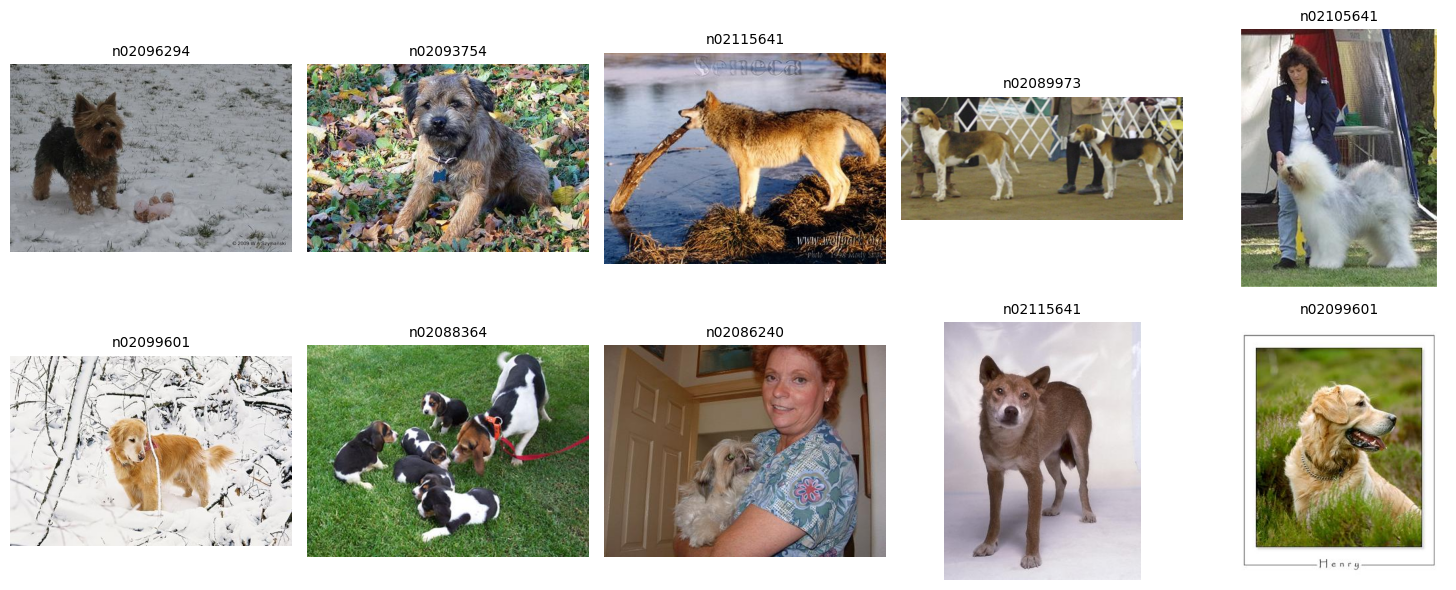

In [ ]:
def visualize_random_samples(n_samples=10):
    """
    Visualiza muestras aleatorias del dataset.
    """
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    random_images = np.random.choice(train_images, n_samples, replace=False)
    
    for idx, img_path in enumerate(random_images):
        img = Image.open(img_path).convert('RGB')
        
        # Obtener clase
        class_id = Path(img_path).parent.name
        class_name = class_id
        
        axes[idx].imshow(img)
        axes[idx].set_title(class_name, fontsize=10)
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_random_samples(10)

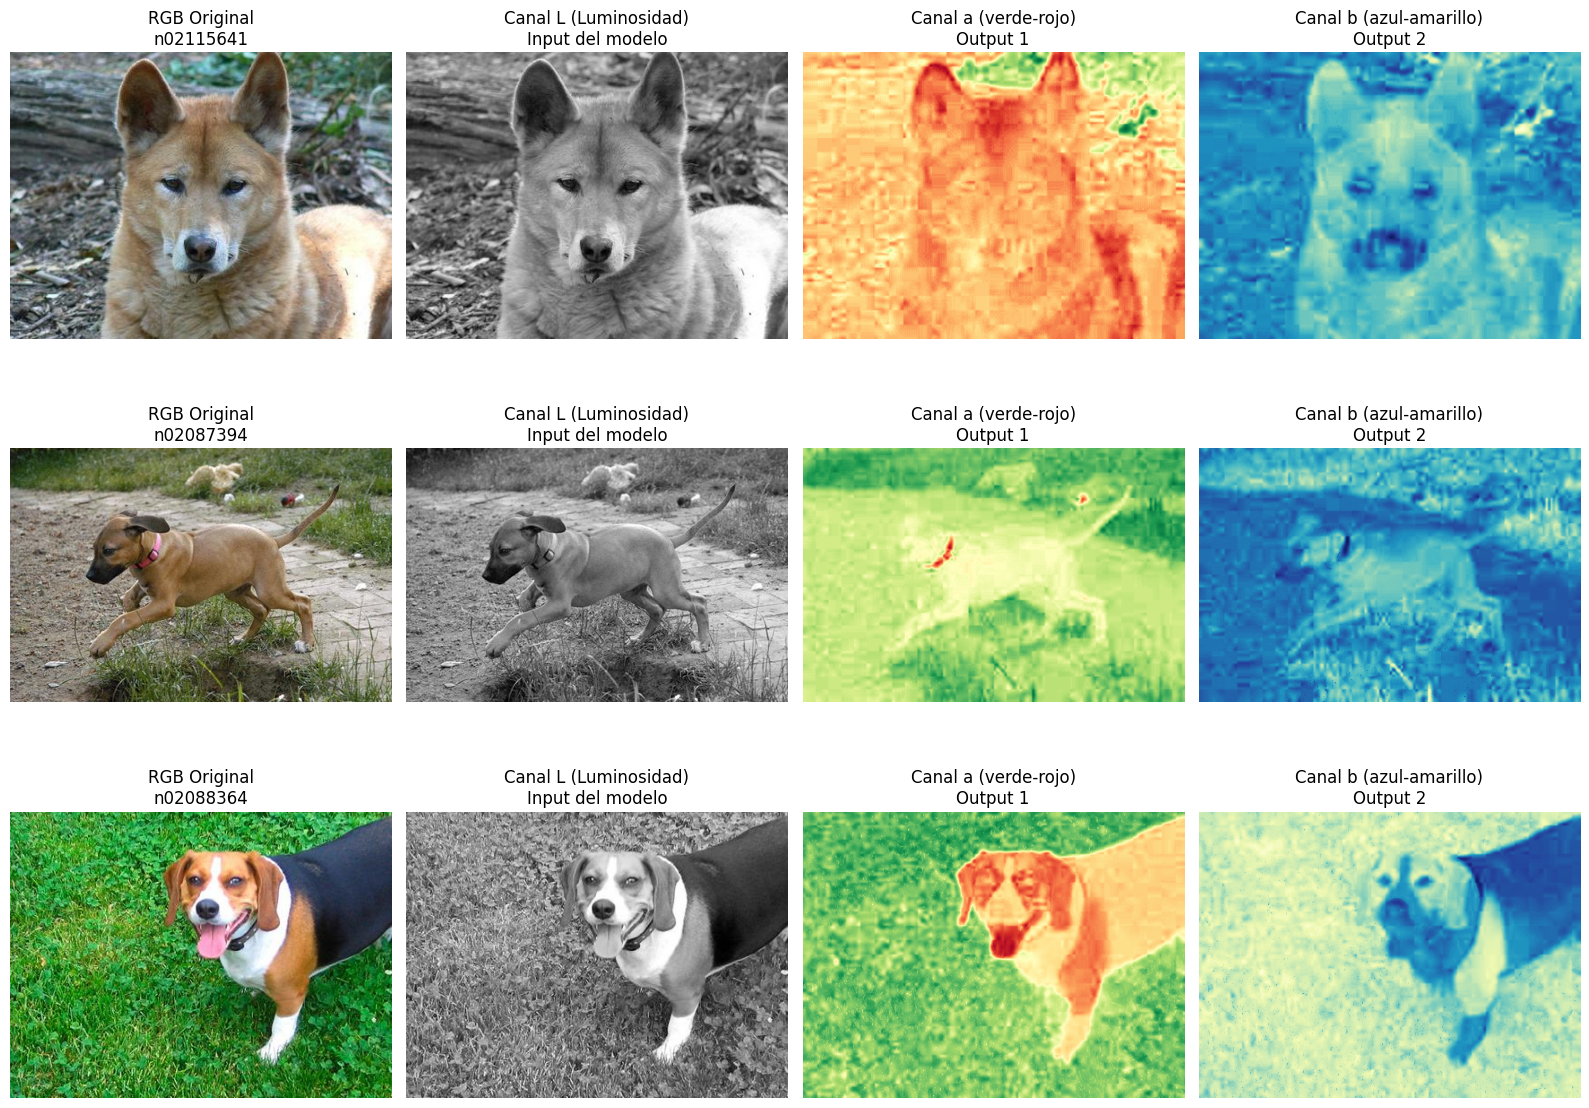

In [ ]:
def visualize_color_spaces(n_samples=3):
    """
    Visualiza el proceso de conversión de espacios de color.
    """
    random_images = np.random.choice(train_images, n_samples, replace=False)
    
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))
    
    for row, img_path in enumerate(random_images):
        # Cargar imagen RGB
        img_rgb = np.array(Image.open(img_path).convert('RGB')) / 255.0
        
        # Convertir a LAB
        img_lab = color.rgb2lab(img_rgb)
        
        # Extraer canales
        L = img_lab[:, :, 0]  # Luminosidad (grayscale)
        a = img_lab[:, :, 1]  # Canal a
        b = img_lab[:, :, 2]  # Canal b
        
        # Obtener clase
        class_id = Path(img_path).parent.name
        class_name = class_id
        
        # Plot
        axes[row, 0].imshow(img_rgb)
        axes[row, 0].set_title(f'RGB Original\n{class_name}')
        axes[row, 0].axis('off')
        
        axes[row, 1].imshow(L, cmap='gray')
        axes[row, 1].set_title('Canal L (Luminosidad)\nInput del modelo')
        axes[row, 1].axis('off')
        
        axes[row, 2].imshow(a, cmap='RdYlGn_r')
        axes[row, 2].set_title('Canal a (verde-rojo)\nOutput 1')
        axes[row, 2].axis('off')
        
        axes[row, 3].imshow(b, cmap='YlGnBu_r')
        axes[row, 3].set_title('Canal b (azul-amarillo)\nOutput 2')
        axes[row, 3].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_color_spaces(3)

### 3. DATA PIPELINE



In [ ]:
def hard_encode_ab(ab_tensor, pts_ab):
    """
    Hard encoding de ab en bins.
    
    Args:
        ab_tensor: tensor de shape (2, H, W) con canales a,b en unidades Lab reales
        pts_ab: tensor de shape (Q, 2) con los centros de los bins
    
    Devuelve:
        q_idx: tensor de shape (H, W) con índices [0, Q-1]
    """
    # Verificar que el tensor venga en forma (H, W, 2)
    if ab_tensor.shape[0] == 2:
        ab_hw2 = ab_tensor.permute(1, 2, 0) # (H, W, 2)
    else:
        ab_hw2 = ab_tensor

    H, W, _ = ab_hw2.shape
    ab_flat = ab_hw2.reshape(-1, 2) # (N, 2), N = H*W

    # Asegurar que esté todo en float
    ab_flat = ab_flat.float()
    pts_ab = pts_ab.to(ab_flat.device).float()  # (Q, 2). Adapta el tensor dependiendo si se usa CPU/GPU

    # Calcular las distancias euclídeas entre píxel-bin (N, Q) y guardar la menor distnacia
    dists = torch.cdist(ab_flat.unsqueeze(0), pts_ab.unsqueeze(0)).squeeze(0)
    q_flat = torch.argmin(dists, dim=1)

    q_idx = q_flat.view(H, W).long()
    
    return q_idx

class ColorizationDataset(Dataset):
    def __init__(self, image_paths, pts_ab, img_size=256, transform=None, return_ab=False):
        """
        Args:
            image_paths: lista de paths a imágenes RGB.
            pts_ab: tensor (Q, 2) con los centros de los bins (en Lab).
            img_size: tamaño al que se reescala la imagen.
        """
        self.image_paths = image_paths
        self.pts_ab = pts_ab
        self.img_size = img_size
        self.transform = transform
        self.return_ab = return_ab

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Cargar imagen RGB
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("RGB")

        # Aplicación de transform (en caso de ser especificado)
        if self.transform is not None:
            img = self.transform(img)
        else:
            # Sino, reescalado a tamaño fijo
            img = img.resize((self.img_size, self.img_size), Image.BILINEAR)

        # Pasar a numpy [0,1]
        rgb_np = np.array(img).astype(np.float32) / 255.0

        # Convertir a Lab
        lab_np = rgb_to_lab(rgb_np)
        L_np = lab_np[:, :, 0]
        ab_np = lab_np[:, :, 1:]

        # Convertir a tensores
        L_tensor = torch.from_numpy(L_np).unsqueeze(0)
        L_tensor = L_tensor.float() / 100.0     # L en [0,1]
        ab_tensor = torch.from_numpy(ab_np).permute(2, 0, 1).float()

        q_idx = hard_encode_ab(ab_tensor, self.pts_ab)

        if self.return_ab:
            return L_tensor, q_idx.long(), ab_tensor
        else:
            return L_tensor, q_idx.long()
    
print("ColorizationDataset definido.")

#### 3.1 Data Augmentation


In [ ]:
# Definición de transformación a aplicar en el set de entrenamiento
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        size=config.IMG_SIZE,
        scale=(0.7, 1.0),
        ratio=(3/4, 4/3),
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02,
    ),
])

print("Data augmentation configurado")
print("Transformaciones: RandomResizedCrop, HorizontalFlip, Rotation, ColorJitter")

#### 3.2 Carga de ResNet50 preentrenado en ImageNet


In [ ]:
backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Ver la arquitectura
print("Arquitectura de ResNet50:")
print(backbone)
print("\n" + "="*50)

# Congelar todos los parámetros
for param in backbone.parameters():
    param.requires_grad = False

print("Todos los parámetros del backbone congelados")

# Mover a device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#### 4 Setup para Modelado

In [ ]:
def generate_ab_bins(grid_size=10, L_value=50):
    """
    Genera la grilla de puntos (a,b) con paso 'grid_size',
    filtra los puntos fuera del rango RGB y devuelve los puntos válidos.
    
    Returns:
        pts_ab: np.ndarray de shape (#valid_points, 2)
    """
    # Se define rango del espacio ab
    ab_range = np.arange(-110, 111, grid_size)
    pts_in = []

    # Recorrer la grilla e incluir en pts_in los puntos dentro del rango válido
    for a in ab_range:
        for b in ab_range:
            lab = np.array([L_value, a, b]).reshape(1, 1, 3)

            # Convertir a RGB para verificar que esté dentro del rango
            rgb = lab_to_rgb(lab)
            
            if (np.all(rgb >= 0.0) and np.all(rgb <= 1.0)):
                pts_in.append([a, b])
    
    pts_in = np.array(pts_in)
    
    return pts_in

# Generar bins
pts_ab_np = generate_ab_bins(grid_size=18, L_value=50)
pts_ab_torch = torch.from_numpy(pts_ab_np)
Q = pts_ab_torch.shape[0]

print(f"Número de clases de color: Q = {Q}")
print(f"Primeros 10 bins:\n{pts_ab_np[:10]}")

# Visualizar distribución de bins
plt.figure(figsize=(8, 8))
plt.scatter(pts_ab_np[:, 0], pts_ab_np[:, 1], c=range(len(pts_ab_np)), 
            cmap='tab20', s=50, alpha=0.6)
plt.xlabel('a*', fontsize=12)
plt.ylabel('b*', fontsize=12)
plt.title(f'Bins de color válidos (Q={Q})', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(-120, 120)
plt.ylim(-120, 120)
plt.colorbar(label='Índice de bin')
plt.tight_layout()
plt.savefig('color_bins_distribution_larsson.png', dpi=150)
plt.show()

print(f"Bins guardados en pts_ab_torch: {pts_ab_torch.shape}")

#### 4.2 Modelo

In [ ]:
class LarssonColorizerClassification(nn.Module):
    """
    Modelo de colorización tipo Larsson (formulación por CLASIFICACIÓN).

    Arquitectura:
    - Encoder: ResNet50 preentrenado (congelado), usando solo el canal L repetido a 3 canales.
    - Fusión multi–scale: concatena features de layer1–4 y los pasa por un bloque de fusión.
    - Decoder: pila de ConvTranspose2d para volver a resolución espacial alta.
    - Output: mapa de logits de color cuantizado (Q clases) para cada píxel.
    """

    def __init__(self, backbone, num_classes):
        super().__init__()

        # Backbone preentrenado (normalmente congelado)
        self.conv1 = backbone.conv1
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        # Detección automática de canales de salida
        C1 = self.layer1[-1].conv3.out_channels if hasattr(self.layer1[-1], "conv3") else self.layer1[-1].conv2.out_channels
        C2 = self.layer2[-1].conv3.out_channels if hasattr(self.layer2[-1], "conv3") else self.layer2[-1].conv2.out_channels
        C3 = self.layer3[-1].conv3.out_channels if hasattr(self.layer3[-1], "conv3") else self.layer3[-1].conv2.out_channels
        C4 = self.layer4[-1].conv3.out_channels if hasattr(self.layer4[-1], "conv3") else self.layer4[-1].conv2.out_channels
        in_channels_fusion = C1 + C2 + C3 + C4

        # Fusión de features
        self.fusion = nn.Sequential(
            nn.Conv2d(in_channels_fusion, 512, kernel_size=3, padding=1), 
            nn.ReLU(inplace=True), 
            nn.Conv2d(512, 256, kernel_size=3, padding=1), 
            nn.ReLU(inplace=True),
        )

        self.unsample = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), 
            nn.ReLU(inplace=True), 
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), 
            nn.ReLU(inplace=True), 
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), 
            nn.ReLU(inplace=True), 
        )

        # Capa final: CLASIFICACIÓN de color
        self.output = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, L):
        """
        Args:
            L: tensor (B, 1, H, W) con el canal L normalizado.

        Returns:
            logits: tensor (B, num_classes, H, W).
        """
        B, _, H, W = L.shape
        x = L.repeat(1, 3, 1, 1)

        # Backbone
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        feat1 = self.layer1(x)
        feat2 = self.layer2(feat1)
        feat3 = self.layer3(feat2)
        feat4 = self.layer4(feat3)

        # Llevar features a igual resolución
        target_size = (8, 8)
        f1 = F.adaptive_avg_pool2d(feat1, target_size)
        f2 = F.adaptive_avg_pool2d(feat2, target_size)
        f3 = F.adaptive_avg_pool2d(feat3, target_size)
        f4 = F.adaptive_avg_pool2d(feat4, target_size)

        features = torch.cat([f1, f2, f3, f4], dim=1)

        # Fusión
        x = self.fusion(features)

        # Unsampling
        x = self.unsample(x)

        # Capa final: logits de color
        logits = self.output(x)

        # Reescalar a resolución original (H, W)
        logits = F.interpolate(
            logits, 
            size=(H, W), 
            mode="bilinear", 
            align_corners=False, 
        )

        return logits

#### 4.3 Preparacion de datasets y Dataloaders

In [ ]:
# Split train/val/test
val_images_shuffled = val_images.copy()
np.random.shuffle(val_images_shuffled)

n_val = len(val_images_shuffled) // 2
val_images_final = val_images_shuffled[:n_val]
test_images_final = val_images_shuffled[n_val:]

print(f"Split del dataset:")
print(f"  Train: {len(train_images)} imágenes")
print(f"  Val: {len(val_images_final)} imágenes")
print(f"  Test: {len(test_images_final)} imágenes")

# Extraer labels de clase
train_labels_list = []
for img_path in train_images:
    class_name = os.path.basename(os.path.dirname(img_path))
    class_idx = class_to_idx[class_name]
    train_labels_list.append(class_idx)

val_labels_list = []
for img_path in val_images_final:
    class_name = os.path.basename(os.path.dirname(img_path))
    class_idx = class_to_idx[class_name]
    val_labels_list.append(class_idx)

print(f"Labels extraídos: train={len(train_labels_list)}, val={len(val_labels_list)}")

# Creación de datasets
train_dataset = ColorizationDataset(
    train_images, 
    pts_ab_torch, 
    img_size=config.IMG_SIZE, 
    transform=train_transform, 
)

val_dataset = ColorizationDataset(
    val_images_final, 
    pts_ab_torch, 
    img_size=config.IMG_SIZE, 
    transform=None, 
    return_ab=True
)

test_dataset = ColorizationDataset(
    test_images_final, 
    pts_ab_torch, 
    img_size=config.IMG_SIZE, 
    transform=None, 
)

# Creación de dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)

print(f"\nDataLoaders creados:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

L_batch, q_batch = next(iter(train_loader))
print("L_batch:", L_batch.shape, L_batch.dtype)
print("q_batch:", q_batch.shape, q_batch.dtype)

#### 4.4 Calculo de Class Weights

In [ ]:
def compute_color_class_weights(train_loader, num_classes, device, lambda_smooth=0.5, max_batches=None):
    """
    Calcula:
        - histogramas de bins de color en todo el train_loader
        - frecuencias p_q
        - pesos balanceados w_q
    
    Args:
        train_loader: DataLoader de entrenamiento.
        num_classes: número de bins Q.
        devivce: 'cuda' o 'cpu'.
        lambda_smooth: lambda para el suavizado de frecuencias.
        
    Returns:
        p_q: tensor (Q,) con frecuencias normalizadas.
        w_q: tensor (Q,) con pesos re-balanceados.
    """
    # Histograma
    hist = torch.zeros(num_classes, dtype=torch.float64)

    with torch.no_grad():
        for b_idx, (L_batch, q_batch) in enumerate(train_loader):
            if max_batches is not None and b_idx >= max_batches:
                break
            
            q_batch = q_batch.to(device)
            
            # Aplanar
            q_flat = q_batch.view(-1)

            # Contar ocurrencias de cada clase presente en el batch
            vals, counts = torch.unique(q_flat, return_counts=True)

            # Sumar al histograma
            hist[vals.cpu()] += counts.cpu().to(hist.dtype)
    
    # Frecuencias normalizadas
    p_q = hist / hist.sum()

    eps = 1e-8
    p_q = torch.clamp(p_q, min=eps)

    Q = float(num_classes)

    # Suavizado de frecuencias
    p_tilde = (1.0 - lambda_smooth) * p_q + (lambda_smooth / Q)

    # Pesos inversos
    w_q = 1.0 / p_tilde

    # Normalizar para que el peso medio sea 1
    norm = (w_q * p_q).sum()
    w_q = w_q / norm

    return p_q.float(), w_q.float()

# Frecuencias normalizadas y pesos re-balanceados
p_q, class_weights = compute_color_class_weights(
    train_loader=train_loader, 
    num_classes=Q, 
    device=device, 
    lambda_smooth=0.5, 
    max_batches=50, 
)
class_weights = class_weights.to(device)

print(f"Class weights calculados para {Q} bins")

#### 4.5 Funciones de Decodificacion y Loss

In [ ]:
def decode_ab_annealed(logits, pts_ab, T=0.4):
    """
    Decodifica logits de clases de color a canales a,b continuos
    usando annealed-mean con temperatura T.
    """
    # Probabilidades por bin
    probs = F.softmax(logits, dim=1)

    # Aplicar temperatura
    if T != 1.0:
        probs = probs ** (1.0 / T)
        probs = probs / probs.sum(dim=1, keepdim=True).clamp_min(1e-8)
    
    pts_ab = pts_ab.to(logits.device).float()

    ab_pred = torch.einsum('bqhw,qc->bchw', probs, pts_ab)

    return ab_pred

def soft_ce_loss(logits, q_idx, soft_encoding_matrix, class_weights=None):
    """
    Cross-entropy con targets suaves (soft-encoding).

    logits: (B, Q, H, W)
    q_idx: (B, H, W)      -- índices duros por píxel
    soft_encoding_matrix: (Q, Q) -- fila i = distribución suave para clase i
    class_weights: (Q,) o None  -- rebalanceo de clases si querés
    """

    B, Q, H, W = logits.shape
    N = B * H * W  # número de píxeles en el batch

    # 1) Aplanamos logits a (N, Q)
    # (B, Q, H, W) -> (B, H, W, Q) -> (N, Q)
    logits_flat = logits.permute(0, 2, 3, 1).reshape(N, Q)

    # 2) Obtenemos los targets suaves para cada píxel: (N, Q)
    q_idx_flat   = q_idx.view(-1)                 # (N,)
    soft_targets = soft_encoding_matrix[q_idx_flat]  # (N, Q)

    # 3) Log-probabilidades predichas: (N, Q)
    log_probs = F.log_softmax(logits_flat, dim=1)

    # 4) Cross-entropy con targets suaves: - ∑ p_true * log p_pred
    loss_per_pixel = -(soft_targets * log_probs).sum(dim=1)  # (N,)

    # 5) Rebajamos o subimos pesos según frecuencia de clase (opcional)
    if class_weights is not None:
        weights = class_weights[q_idx_flat]       # (N,)
        loss_per_pixel = loss_per_pixel * weights

    # 6) Promediamos sobre todos los píxeles
    loss = loss_per_pixel.mean()
    return loss

#### 4.6 Funciones de entrenamiento y validacion

In [ ]:
def calculate_metrics(L_batch, ab_pred, ab_true, lpips_model, device):
    """
    Calcula PSNR, SSIM, Delta E2000 y LPIPS para un batch.
    """
    B = L_batch.shape[0]
    
    psnr_values = []
    ssim_values = []
    delta_e_values = []
    
    # Desnormalizar L
    L_batch_np = (L_batch.cpu().numpy() * 100.0)
    ab_pred_np = ab_pred.cpu().numpy()
    ab_true_np = ab_true.cpu().numpy()
    
    rgb_pred_list = []
    rgb_true_list = []
    
    for i in range(B):
        # Reconstruir LAB
        L = L_batch_np[i, 0]
        ab_p = ab_pred_np[i].transpose(1, 2, 0)
        ab_t = ab_true_np[i].transpose(1, 2, 0)
        
        lab_pred = np.stack([L, ab_p[:,:,0], ab_p[:,:,1]], axis=-1)
        lab_true = np.stack([L, ab_t[:,:,0], ab_t[:,:,1]], axis=-1)
        
        # LAB -> RGB
        rgb_pred = lab_to_rgb(lab_pred)
        rgb_true = lab_to_rgb(lab_true)
        
        # Clip a [0, 1]
        rgb_pred = np.clip(rgb_pred, 0, 1)
        rgb_true = np.clip(rgb_true, 0, 1)
        
        # PSNR
        psnr_val = psnr(rgb_true, rgb_pred, data_range=1.0)
        psnr_values.append(psnr_val)
        
        # SSIM
        ssim_val = ssim(rgb_true, rgb_pred, data_range=1.0, channel_axis=2)
        ssim_values.append(ssim_val)
        
        # Delta E2000
        delta_e = deltaE_ciede2000(lab_true, lab_pred)
        delta_e_values.append(delta_e.mean())
        
        # Guardar para LPIPS
        rgb_pred_list.append(rgb_pred)
        rgb_true_list.append(rgb_true)
    
    # LPIPS
    rgb_pred_tensor = torch.from_numpy(np.array(rgb_pred_list)).permute(0, 3, 1, 2).float().to(device)
    rgb_true_tensor = torch.from_numpy(np.array(rgb_true_list)).permute(0, 3, 1, 2).float().to(device)
    
    # Normalizar a [-1, 1] para LPIPS
    rgb_pred_tensor = rgb_pred_tensor * 2.0 - 1.0
    rgb_true_tensor = rgb_true_tensor * 2.0 - 1.0
    
    with torch.no_grad():
        lpips_val = lpips_model(rgb_pred_tensor, rgb_true_tensor).mean().item()
    
    del rgb_pred_tensor, rgb_true_tensor
    
    return {
        'psnr': np.mean(psnr_values),
        'ssim': np.mean(ssim_values),
        'delta_e': np.mean(delta_e_values),
        'lpips': lpips_val
    }

def train_epoch(model, train_loader, soft_enc_matrix, class_w, optimizer, device):
    """
    Entrena el modelo por una época.
    """
    model.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc="Training")
    for L, q_idx in pbar:
        L = L.to(device)
        q_idx = q_idx.to(device)

        # Forward
        logits = model(L)
        loss = soft_ce_loss(
            logits, 
            q_idx, 
            soft_enc_matrix, 
            class_w, 
        )

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Carga de datos
        running_loss += loss.item()
        pbar.set_postfix({"loss": loss.item()})
    
    epoch_loss = running_loss / len(train_loader)

    return epoch_loss

def validate_epoch(model, val_loader, soft_enc_matrix, class_w, device, pts_ab, 
                   lpips_model, compute_metrics=True, T=0.4, max_batches_metrics=50):
    """
    Valida el modelo con métricas de calidad.
    """

    model.eval()
    running_loss = 0.0

    # Acumulador de métricas por batch
    metrics_accum = {
        "psnr": [],
        "ssim": [],
        "delta_e": [],
        "lpips": [],
    }

    pts_ab_gpu = pts_ab.to(device)

    with torch.no_grad():
        pbar = tqdm(val_loader, desc="Validation")

        for batch_idx, batch in enumerate(pbar):
            # --- 1) Desempaquetar batch ---
            # val_loader devuelve (L, q_idx, ab_true) porque return_ab=True
            if len(batch) == 3:
                L, q_idx, ab_true = batch
            else:
                # por si acaso, compatibilidad si alguna vez usás return_ab=False
                L, q_idx = batch
                ab_true = None

            L = L.to(device)
            q_idx = q_idx.to(device)
            if ab_true is not None:
                ab_true = ab_true.to(device)

            # --- 2) Forward y pérdida ---
            logits = model(L)
            loss = soft_ce_loss(
                logits,
                q_idx,
                soft_enc_matrix,
                class_w,
            )

            running_loss += loss.item()

            # --- 3) Métricas de calidad (solo en algunos batches) ---
            if (
                compute_metrics
                and (ab_true is not None)
                and batch_idx < max_batches_metrics
            ):
                # Decodificar ab predicho (en unidades LAB reales)
                ab_pred = decode_ab_annealed(logits, pts_ab_gpu, T=T)  # (B,2,H,W)

                # Calcular métricas para este batch
                batch_metrics = calculate_metrics(
                    L,          # (B,1,H,W) en [0,1]
                    ab_pred,    # (B,2,H,W) predicho
                    ab_true,    # (B,2,H,W) ground truth continuo
                    lpips_model,
                    device,
                )

                # Guardar para promedio
                for key in metrics_accum:
                    metrics_accum[key].append(batch_metrics[key])

                # liberar algo de memoria
                del ab_pred

            # --- 4) Actualizar barra de progreso ---
            postfix = {"val_loss": f"{loss.item():.4f}"}

            if compute_metrics and len(metrics_accum["psnr"]) > 0:
                postfix["psnr"] = f"{np.mean(metrics_accum['psnr']):.2f}"
                postfix["ssim"] = f"{np.mean(metrics_accum['ssim']):.3f}"

            pbar.set_postfix(postfix)

            if batch_idx % 10 == 0:
                torch.cuda.empty_cache()

    # --- 5) Promedios finales ---
    epoch_loss = running_loss / len(val_loader)

    results = {"val_loss": epoch_loss}

    if compute_metrics and len(metrics_accum["psnr"]) > 0:
        results["psnr"] = float(np.mean(metrics_accum["psnr"]))
        results["ssim"] = float(np.mean(metrics_accum["ssim"]))
        results["delta_e"] = float(np.mean(metrics_accum["delta_e"]))
        results["lpips"] = float(np.mean(metrics_accum["lpips"]))

    return results

print("Funciones de entrenamiento y validación definidas.")


#### 4.8 Inicializar LPIPS

In [ ]:
import gc

try:
    import lpips
except:
    import subprocess
    subprocess.check_call(['pip', 'install', 'lpips'])
    import lpips

lpips_model = lpips.LPIPS(net='alex').to(device)
print("LPIPS inicializado")

# Limpiar memoria
torch.cuda.empty_cache()
gc.collect()
print("Memoria GPU limpiada")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /home/felip/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 201MB/s] 


Loading model from: /opt/conda/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
LPIPS inicializado
Memoria GPU limpiada


#### 5 Entrenamiento del Modelo

In [ ]:
def build_soft_encoding_matrix(pts_ab, T=0.5, K=5):
    """
    Construye una matriz (Q, Q) donde cada fila i es una distribución
    suave sobre las Q clases, concentrada en los K vecinos más cercanos
    del bin i en el espacio ab.

    pts_ab: tensor (Q, 2) con los centros de los bins en coordenadas ab reales.
    T: temperatura (más chico = distribución más picuda).
    K: cantidad de vecinos (incluyendo el propio bin).
    """

    # Aseguramos que esté en float32
    pts_ab = pts_ab.to(torch.float32)
    Q = pts_ab.shape[0]

    # Distancias euclídeas entre cada par de bins: (Q, Q)
    # dist[i, j] = distancia entre bin i y bin j en el plano ab
    dist = torch.cdist(pts_ab, pts_ab, p=2)  # (Q, Q)

    # Inicializamos puntajes con -inf
    scores = torch.full_like(dist, -float("inf"))

    # K vecinos más cercanos para cada fila (incluye al propio bin)
    knn_vals, knn_idx = dist.topk(K, dim=1, largest=False)  # (Q, K)

    # Rellenamos solo los K vecinos con -dist/T (más cerca = mayor score)
    scores.scatter_(1, knn_idx, -knn_vals / T)

    # Softmax por fila -> cada fila es una distribución de probabilidad
    soft_enc = F.softmax(scores, dim=1)  # (Q, Q)
    return soft_enc

In [ ]:
# Construir matriz de probabilidades para soft_encoding
soft_encoding_matrix = build_soft_encoding_matrix(
    pts_ab_torch, 
    T=0.5, 
    K=5, 
).to(device)

# Crear modelo
model_LCC = LarssonColorizerClassification(
    backbone=backbone, num_classes=Q
).to(device)

# Optimizador
optimizer = optim.Adam(
    model_LCC.parameters(), 
    lr=config.LEARNING_RATE, 
    weight_decay=config.WEIGHT_DECAY, 
)

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=2, 
    threshold=0.01, 
    min_lr=1e-5, 
)

In [ ]:
NUM_EPOCHS = config.NUM_EPOCHS
PATIENCE = config.PATIENCE

history = {
    "train_loss": [], 
    "val_loss" : [], 
    "lr": [], 
}

best_val_loss = float("inf")
epochs_without_improvement = 0

print(f"Iniciando entrenamiento por {NUM_EPOCHS} épocas (patience={PATIENCE})")

for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")

    # Entrenamiento
    train_loss = train_epoch(model_LCC, train_loader, soft_encoding_matrix, class_weights, optimizer, device)

    # Validación
    val_results = validate_epoch(model_LCC, val_loader, soft_encoding_matrix, class_weights, device, pts_ab_torch, 
                                 lpips_model=lpips_model, compute_metrics=True, T=0.38, max_batches_metrics=30)
    val_loss = val_results["val_loss"]

    # Scheduler
    scheduler.step(val_loss)
    current_lr = optimizer.para_groups[0]["lr"]

    # Guardar en history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)

    print(f"Train loss: {train_loss:.4f}")
    print(f" Validation loss: {val_loss:.4f}")
    print(f"Learning-Rate: {current_lr:.6f}")

    if 'psnr' in val_results:
        print(f"  Metrics: PSNR={val_results['psnr']:.2f} SSIM={val_results['ssim']:.3f} DeltaE={val_results['delta_e']:.2f} LPIPS={val_results['lpips']:.3f}")

    # Early stopping y guardado de mejor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0

        # Métricas de esta época
        best_metrics = {
            k: v for k, v in val_results.items()
            if k != "val_loss"
        }

        torch.save(model_LCC.state_dict(), "best_larsson_classification.pth")
        print(">> Mejor modelo guardado.")
    else:
        epochs_without_improvement += 1
        print(f"Sin mejora por {epochs_without_improvement} épocas.")

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping: no hubo mejoras en {PATIENCE} épocas.")
        break

    print ("-" * 50)

print("\nEntrenamiento temrinado.")
print(f"Mejor val_loss: {best_val_loss:.4f}")

if best_metrics:
    print("\nMejores métricas (época de mejor modelo):")
    for k, v in best_metrics.items():
        print(f"  {k.upper():>7}: {v:.3f}")

#### 6 Visualizacion Final

In [ ]:
def visualize_colorization(model, dataloader, pts_ab, n_samples=5, device="cuda", T=0.4):
    """
    Visualiza resultados de colorización usando modelo de CLASIFICACIÓN.

    - model: LarssonColorizerClassification
    - dataloader: típicamente val_loader (idealmente shuffle=False)
    - pts_ab: tensor (Q, 2) con centros de los bins en UNIDADES LAB REALES
    """

    model.eval()

    # 1) Tomar un batch de L del dataloader
    batch = next(iter(dataloader))

    # Tu loader puede devolver (L, q_idx) o (L, q_idx, ab) según return_ab
    if isinstance(batch, (list, tuple)):
        if len(batch) == 2:
            L_batch, _ = batch
        elif len(batch) == 3:
            L_batch, _, _ = batch
        else:
            raise ValueError(f"Batch con longitud inesperada: {len(batch)}")
    else:
        # Por si acaso, si solo viniera L
        L_batch = batch

    L_batch = L_batch.to(device)   # (B,1,H,W), L normalizada [0,1]

    # 2) Forward del modelo + decodificación annealed-mean
    with torch.no_grad():
        logits = model(L_batch)                         # (B,Q,H,W)
        ab_pred = decode_ab_annealed(logits, pts_ab, T=T)  # (B,2,H,W)

    B = L_batch.shape[0]
    n_samples = min(n_samples, B)

    # Dataset subyacente para recuperar las imágenes originales
    dataset = dataloader.dataset

    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4 * n_samples))
    if n_samples == 1:
        axes = axes[None, :]  # para que siempre tengamos [i, j]

    for i in range(n_samples):

        # 3) Input L (lo que ve el modelo)
        L_norm = L_batch[i, 0].detach().cpu().numpy()   # (H,W) en [0,1]
        L_real = L_norm * 100.0                         # (H,W) en [0,100]
        H, W = L_real.shape

        # 4) Ground truth original: cargar RGB desde disco
        if hasattr(dataset, "image_files"):
            img_path = dataset.image_files[i]
        elif hasattr(dataset, "image_paths"):
            img_path = dataset.image_paths[i]
        else:
            raise AttributeError(
                "El dataset no tiene atributos 'image_files' ni 'image_paths'. "
                "Adaptá esta parte a tu implementación de ColorizationDataset."
            )

        img = Image.open(img_path).convert("RGB")
        img = img.resize((W, H), Image.BILINEAR)
        rgb_true = np.array(img).astype(np.float32) / 255.0  # (H,W,3) en [0,1]

        # Pasar a LAB para obtener ab verdaderos
        lab_true_full = rgb_to_lab(rgb_true)    # (H,W,3) con L en [0,100]
        ab_true = lab_true_full[:, :, 1:]       # (H,W,2)

        # 5) Predicción del modelo (annealed-mean)
        ab_pred_np = ab_pred[i].detach().cpu().numpy()   # (2,H,W)
        ab_pred_np = np.transpose(ab_pred_np, (1, 2, 0)) # (H,W,2)

        # 6) Reconstruir LAB completo para GT y predicción,
        #    usando el mismo L_real que alimentaste al modelo
        lab_true = np.zeros((H, W, 3), dtype=np.float32)
        lab_pred = np.zeros((H, W, 3), dtype=np.float32)

        lab_true[:, :, 0] = L_real
        lab_true[:, :, 1:] = ab_true

        lab_pred[:, :, 0] = L_real
        lab_pred[:, :, 1:] = ab_pred_np

        # 7) Convertir a RGB para visualizar
        rgb_true_vis = lab_to_rgb(lab_true)
        rgb_pred_vis = lab_to_rgb(lab_pred)

        rgb_true_vis = np.clip(rgb_true_vis, 0, 1)
        rgb_pred_vis = np.clip(rgb_pred_vis, 0, 1)

        # 8) Mapa de error en espacio ab
        error_map = np.linalg.norm(ab_true - ab_pred_np, axis=2)  # (H,W)
        error_map = error_map / (np.max(error_map) + 1e-8)

        # 9) Plots
        axes[i, 0].imshow(L_real, cmap="gray")
        axes[i, 0].set_title("Input (Grayscale)")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(rgb_true_vis)
        axes[i, 1].set_title("Ground Truth (original)")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(rgb_pred_vis)
        axes[i, 2].set_title("Predicted (annealed-mean)")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(error_map, cmap="magma")
        axes[i, 3].set_title("Error Map")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()